In [1]:
# Install packages, only needed for first time use 
%pip install numpy matplotlib scikit-image pandas seaborn natsort cellpose
# activate env 
# .\cellpose_env\Scripts\Activate.ps1


In [2]:
# -------------------------------
# IMPORTS
# -------------------------------
# multi image cellpose
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.measure import regionprops
from cellpose import models, plot
import pandas as pd
import seaborn as sns
from pathlib import Path
from natsort import natsorted

In [ ]:
# -------------------------------
# 1️⃣ PARAMETERS
# -------------------------------

# --- Auto-detect environment ---
try:
    import google.colab  # only exists inside Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Mount Google Drive so your images are accessible
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    # Edit this to match where your experiment folder lives in Drive:
    image_folder = Path("/content/drive/MyDrive/Psychatg02_07112025/Psychatg02_07112025")
else:
    # Local Windows kernel path
    image_folder = Path("C:/Users/b1810/Desktop/coding/images/Psychatg02_07112025/Psychatg02_07112025")

print(f"Running in Colab: {IN_COLAB}")

condition1 = 'S+B+'
condition2 = 'S-B+'

condition1_folder = image_folder / "S+B+_w1"
condition2_folder = image_folder / "B-S-_w1"

print(condition1_folder)
print(condition2_folder)

# try to add parameters that will be used later in the code
# search_only = ch2.tif or ch1.tif
# diameter = 30                # approx. size of cells
# flow_threshold = 0.4
# cellprob_threshold = 0.0

Mounted at /content/drive
Running in Colab: True
/content/drive/MyDrive/Psychatg02_07112025/Psychatg02_07112025/S+B+_w1
/content/drive/MyDrive/Psychatg02_07112025/Psychatg02_07112025/B-S-_w1


In [18]:
# --- DIAGNOSTIC: run this to verify the kernel can see your files ---
import sys
print('Python executable:', sys.executable)
print('Platform:', sys.platform)
print('image_folder exists:', image_folder.exists())
print('condition1_folder exists:', condition1_folder.exists())
print('condition2_folder exists:', condition2_folder.exists())

# List up to 5 matched files to confirm pattern works
found = list(image_folder.glob('**/HM_*_CH2.tif'))[:5]
print(f'Sample files found ({len(found)} shown):')
for f in found:
    print(' ', f)

# ------------------------------
# 2️⃣ LOAD IMAGES
# ------------------------------
condition1_files = natsorted(list(condition1_folder.glob('**/HM_*_CH2.tif')))
condition2_files = natsorted(list(condition2_folder.glob('**/HM_*_CH2.tif')))
print(f'Condition 1 files: {len(condition1_files)}')
print(f'Condition 2 files: {len(condition2_files)}')

Python executable: /usr/bin/python3
Platform: linux
image_folder exists: False
condition1_folder exists: False
condition2_folder exists: False
Sample files found (0 shown):
Condition 1 files: 0
Condition 2 files: 0


In [19]:
# -------------------------------
# 3️⃣ INIT CELLPOSE MODEL
# -------------------------------
model = models.CellposeModel(gpu=True)  # or path to a custom model

In [20]:

# INITIALIZATION (MUST BE RUN BEFORE THE FUNCTION IS CALLED)

# Load model (if not already)
model = models.CellposeModel(gpu=True)

# Store all image arrays, mask arrays, and flow arrays globally
all_images = []
all_masks = []
all_flows = []

def run_cell_analysis(ch2_path, file_id):
    """
    Performs Cellpose segmentation and feature extraction for a single image pair.
    The data is appended to the global 'rows' list.
    """
    print(f"/n--- Analyzing file: {os.path.basename(ch2_path)} ---")

    # Declare the lists as global so we can modify them
    global all_images 
    global all_masks 
    global all_flows
    
    rows = [] 
    # Assume ch2_path is the full path string (e.g., '.../HM_W001_P00001_CH2.tif')
    ch4_path = ch2_path.replace("_CH2.tif", "_CH4.tif")
    # 1. Load Images (as 2D grayscale)
    ch1_img = io.imread(ch2_path, as_gray=True)
    ch4_img = io.imread(ch4_path, as_gray=True)

    # 2. Run Cellpose (on the ch1/GFP channel)
    masks, flows, styles = model.eval([ch1_img],
                                      diameter=30,
                                      flow_threshold=2,
                                      cellprob_threshold=1)
    current_mask = masks[0] 
    current_flow = flows[0]

    all_images.append(ch1_img)
    all_masks.append(current_mask)
    all_flows.append(current_flow)
    
# 3. Measure Properties for BOTH channels using the SAME masks
    props = regionprops(current_mask, intensity_image=ch1_img) # Use current_mask
    ch4_props = regionprops(current_mask, intensity_image=ch4_img) # Use current_mask
    
    # Get File Name (for tracking)
    file_name = os.path.splitext(os.path.basename(ch2_path))[0]

    # 4. COMBINE DATA INTO ONE ROW PER CELL (The main fix)
    # The 'props' and 'ch4_props' lists are guaranteed to be in the same order 
    # and correspond to the same labels, so we use zip().
    for p_gfp, p_s647 in zip(props, ch4_props):
        rows.append({
            "file": file_name,
            "primary_id": file_id,
            "cell_id": p_gfp.label,
            "area_px": p_gfp.area,
            "mean_gfp": p_gfp.mean_intensity,
            "mean_s647": p_s647.mean_intensity # Both intensities are now in one row
        })
    
    #return the data as a dataframe
    return pd.DataFrame(rows)
    

In [21]:
# -------------------------------
# 4️⃣ RUN SEGMENTATION
# -------------------------------

print(f"Condition 1 folder exists: {condition1_folder.exists()} -> {condition1_folder}")
print(f"Condition 2 folder exists: {condition2_folder.exists()} -> {condition2_folder}")
print(f"Condition 1 files found: {len(condition1_files)}")
print(f"Condition 2 files found: {len(condition2_files)}")

expected_columns = ["file", "primary_id", "cell_id", "area_px", "mean_gfp", "mean_s647"]

df_list_condition1 = []  # Initialize an empty list to store results
file_id_counter = 1

# Loop through Condition 1 files
for f in condition1_files:
    # 1. Call the function and capture the returned DataFrame
    df_single_file = run_cell_analysis(str(f), file_id=file_id_counter)
    # 2. Append the single-file DataFrame to the list
    df_list_condition1.append(df_single_file)
    # 3. Increment the counter so the next file gets the next ID
    file_id_counter += 1
    print("\n--- Analyzing file ---")

if df_list_condition1:
    df_condition1 = pd.concat(df_list_condition1, ignore_index=True)
else:
    print("Warning: No Condition 1 files were processed. Returning empty DataFrame.")
    df_condition1 = pd.DataFrame(columns=expected_columns)

print(f"df_condition1 now has {len(df_condition1)} rows.")

df_list_condition2 = []
for f in condition2_files:
    df_single_file = run_cell_analysis(str(f), file_id=file_id_counter)
    df_list_condition2.append(df_single_file)
    print("\n--- Analyzing file ---")
    file_id_counter += 1

if df_list_condition2:
    df_condition2 = pd.concat(df_list_condition2, ignore_index=True)
else:
    print("Warning: No Condition 2 files were processed. Returning empty DataFrame.")
    df_condition2 = pd.DataFrame(columns=expected_columns)

print(f"df_condition2 now has {len(df_condition2)} rows.")

Condition 1 folder exists: False -> /content/drive/MyDrive/Psychatg02_07112025/Psychatg02_07112025/S+B+_w1
Condition 2 folder exists: False -> /content/drive/MyDrive/Psychatg02_07112025/Psychatg02_07112025/B-S-_w1
Condition 1 files found: 0
Condition 2 files found: 0
df_condition1 now has 0 rows.
df_condition2 now has 0 rows.


In [22]:
df_condition1

,file,primary_id,cell_id,area_px,mean_gfp,mean_s647


In [9]:
#concat the S+ and S-
df_condition1['Condition'] = condition1
df_condition2['Condition'] = condition2

# Combine the two DataFrames
df_combined = pd.concat([df_condition1, df_condition2], ignore_index=True)
df_combined['ratio_s647_gfp'] = df_combined['mean_s647'] / (df_combined['mean_gfp'] + 1e-9) #added 1e-9 to help with no gfp errors 

In [10]:
df_combined.head(800)

,file,primary_id,cell_id,area_px,mean_gfp,mean_s647,Condition,ratio_s647_gfp


In [11]:
# sum_num = 0
# temp = df_combined['primary_id'].iloc[0]
# total_num = 0
# index = 0
# average= []

# for value in df_combined['primary_id']:
#     if (temp == value):
#        # print ("here")
#         sum_num = sum_num + df_combined['ratio_s647_gfp'].iloc[index]
#         #print (sum_num, "and", total_num)
#         total_num = total_num + 1
#         temp=value
#         index = index + 1
#     else:
#         average.append(sum_num/total_num)
#       #  print ("here")
#         sum_num = 0
#         total_num = 0
#         temp=value
#         index = index + 1
# average.append(sum_num/total_num)
# print (average)

In [12]:

avg = df_combined.loc[(df_combined['primary_id'] == 1) & (df_combined['Condition'] == 'S+B+'), 'ratio_s647_gfp'].mean()
print (avg)

nan


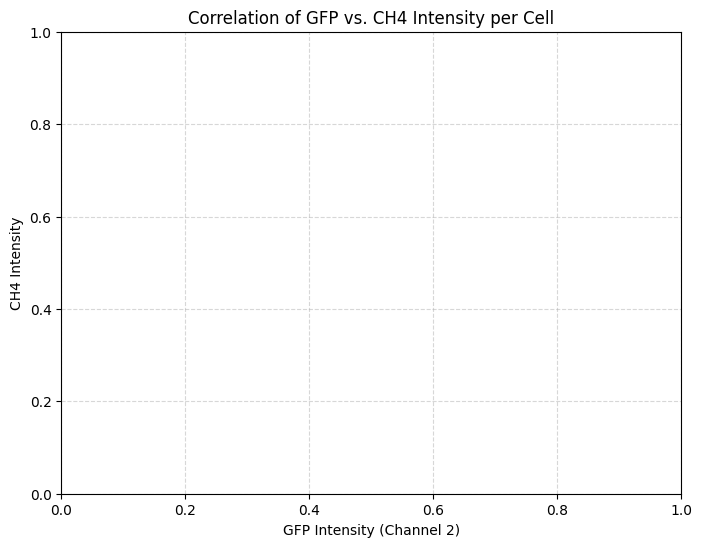

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_combined,
    x='mean_gfp',
    y='mean_s647',
    hue='Condition',  # Use the new column to distinguish colors
    s = 10,
    alpha=0.7         # Set transparency for better visibility of overlapping points
)

plt.xlabel("GFP Intensity (Channel 2)")
plt.ylabel("CH4 Intensity")
plt.title("Correlation of GFP vs. CH4 Intensity per Cell")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<Axes: >

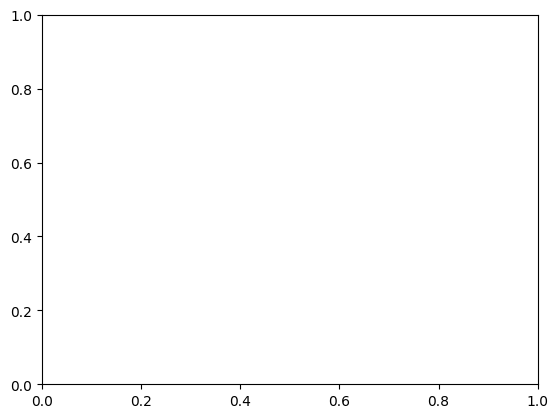

In [14]:
#violin plot 
sns.violinplot(
    data=df_combined,
    x='Condition',
    y='ratio_s647_gfp',
    hue='Condition',  # ADDED: Assign x to hue as recommended
    legend=False,     # ADDED: Hide the redundant legend
    palette=['blue', 'gray'],
    order=['S-B+', 'S+B+']
)

In [15]:
from cellpose import plot
import numpy as np

# Assuming 'img' is your original image and 'masks' is the array of masks
# The 'masks' array is one of the outputs from model.eval() or loaded from a '_seg.npy' file

mask_RGB = plot.mask_overlay(img, masks, colors=np.array(dat['colors']))
plt.imshow(mask_RGB)
plt.show()

NameError: name 'img' is not defined

In [ ]:
from cellpose import utils
import matplotlib.pyplot as plt

# Assuming 'img' is your original image and 'mask' is the 2D mask array
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray') # Show the original image first

# 1. Get the outlines
outlines = utils.outlines_list(mask)

# 2. Plot the outlines
for outline in outlines:
    # outline is a list of (y, x) coordinates for the boundary
    plt.plot(outline[:, 1], outline[:, 0], color='red', linewidth=1) 
    
plt.title("Outlines over Original Image")
plt.axis('off')
plt.show()

NameError: name 'img' is not defined

<Figure size 800x800 with 0 Axes>

In [ ]:
# -------------------------------
# 5️⃣ PLOT EXAMPLES (image + mask + flow)
# -------------------------------
for i in range(min(3, len(images))):  # show first 3 images
    img = images[i]
    mask = all_masks[i]
    flow = all_flows[i]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original
    axes[0].imshow(img if img.ndim==2 else img[..., :3])
    axes[0].set_title("Original image")
    axes[0].axis('off')

    # Mask overlay
    overlay = label2rgb(mask, image=img if img.ndim==2 else img[..., :3], bg_label=0, alpha=0.3)
    axes[1].imshow(overlay)
    axes[1].set_title("Mask overlay")
    axes[1].axis('off')

    # Flow visualization
    flow_x, flow_y = flow[1][0], flow[1][1]
    axes[2].imshow(img if img.ndim==2 else img[..., :3], cmap='gray')
    step = max(1, flow_x.shape[0] // 40)
    axes[2].quiver(np.arange(0, flow_x.shape[1], step),
                   np.arange(0, flow_y.shape[0], step),
                   flow_x[::step, ::step],
                   flow_y[::step, ::step],
                   color='red', scale=40)
    axes[2].set_title("Flow field")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

NameError: name 'images' is not defined

In [ ]:
# Select which image/mask pair to display. 
# Index 0 is the first image, 1 is the second, etc.
# Check Cell In[53] to see how many files were processed.

# --- CHANGE THIS INDEX TO PLOT A DIFFERENT IMAGE ---
image_index = 0  # To plot the *first* image processed (HM_W001_P00001_CH2.tif)

# 1. Assign the variables
img = all_images[image_index]
mask = all_masks[image_index]

# 2. Print the shape to confirm data is loaded
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask.shape}")

IndexError: list index out of range

In [ ]:
# (Cell In[51] - The outline plotting code)
from cellpose import utils
import matplotlib.pyplot as plt

# Assuming 'img' is your original image and 'mask' is the 2D mask array
plt.figure(figsize=(8, 8))
plt.imshow(img) # Show the original image first

# 1. Get the outlines
outlines = utils.outlines_list(mask)

# 2. Plot the outlines
for outline in outlines:
    # outline is a list of (y, x) coordinates for the boundary
    plt.plot(outline[:, 1], outline[:, 0], color='red', linewidth=1) 
    
plt.title("Outlines over Original Image")
plt.axis('off')
plt.show()

NameError: name 'img' is not defined

<Figure size 800x800 with 0 Axes>